In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Sep:\s+,存在两种或两种以上的参数设置
df_train = pd.read_csv('./data/二手车预测/used_car_train_20200313/used_car_train_20200313.csv',sep='\s+')
df_test = pd.read_csv('./data/二手车预测/used_car_testB_20200421/used_car_testB_20200421.csv',sep='\s+')

In [3]:
print('df_train shape:',df_train.shape)
print('df_test.shape:',df_test.shape)

df_train shape: (150000, 31)
df_test.shape: (50000, 30)


In [4]:
df_train.head()

,SaleID,name,regDate,model,brand,bodyType,fuelType,gearbox,power,kilometer,...,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,v_13,v_14
0,0,736,20040402,30.0,6.0,1.0,0.0,0.0,60,12.5,...,0.235676,0.101988,0.129549,0.022816,0.097462,-2.881803,2.804097,-2.420821,0.795292,0.914762
1,1,2262,20030301,40.0,1.0,2.0,0.0,0.0,0,15.0,...,0.264777,0.121004,0.135731,0.026597,0.020582,-4.900482,2.096338,-1.030483,-1.722674,0.245522
2,2,14874,20040403,115.0,15.0,1.0,0.0,0.0,163,12.5,...,0.251410,0.114912,0.165147,0.062173,0.027075,-4.846749,1.803559,1.565330,-0.832687,-0.229963
3,3,71865,19960908,109.0,10.0,0.0,0.0,1.0,193,15.0,...,0.274293,0.110300,0.121964,0.033395,0.000000,-4.509599,1.285940,-0.501868,-2.438353,-0.478699
4,4,111080,20120103,110.0,5.0,1.0,0.0,0.0,68,5.0,...,0.228036,0.073205,0.091880,0.078819,0.121534,-1.896240,0.910783,0.931110,2.834518,1.923482


In [5]:
df_train.info()#查看缺失情况

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SaleID             150000 non-null  int64  
 1   name               150000 non-null  int64  
 2   regDate            150000 non-null  int64  
 3   model              150000 non-null  float64
 4   brand              150000 non-null  float64
 5   bodyType           150000 non-null  float64
 6   fuelType           150000 non-null  float64
 7   gearbox            150000 non-null  object 
 8   power              150000 non-null  object 
 9   kilometer          150000 non-null  object 
 10  notRepairedDamage  150000 non-null  object 
 11  regionCode         150000 non-null  int64  
 12  seller             150000 non-null  int64  
 13  offerType          150000 non-null  float64
 14  creatDate          150000 non-null  float64
 15  price              150000 non-null  float64
 16  v_

In [6]:
df_train.columns

Index(['SaleID', 'name', 'regDate', 'model', 'brand', 'bodyType', 'fuelType',
       'gearbox', 'power', 'kilometer', 'notRepairedDamage', 'regionCode',
       'seller', 'offerType', 'creatDate', 'price', 'v_0', 'v_1', 'v_2', 'v_3',
       'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12',
       'v_13', 'v_14'],
      dtype='object')

In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SaleID             50000 non-null  int64  
 1   name               50000 non-null  int64  
 2   regDate            50000 non-null  int64  
 3   model              50000 non-null  float64
 4   brand              50000 non-null  int64  
 5   bodyType           50000 non-null  float64
 6   fuelType           50000 non-null  float64
 7   gearbox            50000 non-null  object 
 8   power              50000 non-null  object 
 9   kilometer          50000 non-null  object 
 10  notRepairedDamage  50000 non-null  object 
 11  regionCode         50000 non-null  int64  
 12  seller             50000 non-null  float64
 13  offerType          50000 non-null  float64
 14  creatDate          50000 non-null  float64
 15  v_0                50000 non-null  float64
 16  v_1                500

In [14]:
#数据信息统计概览
df_train.describe()

,SaleID,name,regDate,model,brand,bodyType,fuelType,regionCode,seller,offerType,...,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,v_13,v_14
count,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,1.500000e+05,1.500000e+05,...,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,148531.000000,146417.000000,135884.000000
mean,74999.500000,68349.172873,2.003417e+07,47.128953,8.052527,1.870747,1.394827,1.997783e+05,2.841478e+05,1.415701e+06,...,0.246643,0.062381,0.174574,0.296920,0.406928,-0.164371,-0.446352,-0.085471,0.022190,0.008456
std,43301.414527,61103.875095,5.364988e+04,49.535881,7.864603,5.221312,15.676749,1.985073e+06,2.376421e+06,5.151321e+06,...,0.116636,0.133581,0.927042,1.773396,1.962003,3.758661,2.002930,2.257730,1.267140,1.050417
min,0.000000,0.000000,1.991000e+07,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,-0.273510,-8.206004,-8.399672,-9.168192,-9.404106,-9.639552,-6.113291,-6.546556
25%,37499.750000,11156.000000,1.999091e+07,10.000000,1.000000,0.000000,0.000000,7.390000e+02,0.000000e+00,0.000000e+00,...,0.241064,0.000161,0.055272,0.036050,0.035225,-3.666042,-2.026105,-1.745234,-0.999703,-0.426907
50%,74999.500000,51638.000000,2.003091e+07,30.000000,6.000000,1.000000,0.000000,2.010000e+03,0.000000e+00,0.000000e+00,...,0.256928,0.001547,0.090081,0.058523,0.063335,1.240603,-0.457218,-0.160305,0.008602,0.155026
75%,112499.250000,118841.250000,2.007111e+07,66.000000,13.000000,3.000000,1.000000,3.719000e+03,0.000000e+00,0.000000e+00,...,0.265170,0.104255,0.120590,0.081996,0.094738,2.691063,1.115744,1.572130,0.929041,0.700543
max,149999.000000,196812.000000,2.015121e+07,247.000000,39.000000,999.000000,3500.000000,2.016041e+07,2.016041e+07,2.016041e+07,...,1.401999,1.387847,12.357011,18.819042,18.801218,18.802072,13.562011,11.147669,8.658418,2.743993


df_test.describe()

### 特征工程

In [15]:
#1.提取数值类型
numerical_cols = df_train.select_dtypes(exclude = 'object').columns

In [16]:
print(numerical_cols)

Index(['SaleID', 'name', 'regDate', 'model', 'brand', 'bodyType', 'fuelType',
       'regionCode', 'seller', 'offerType', 'creatDate', 'price', 'v_0', 'v_1',
       'v_2', 'v_3', 'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11',
       'v_12', 'v_13', 'v_14'],
      dtype='object')


In [17]:
categorical_cols = df_train.select_dtypes(include = 'object').columns
print(categorical_cols)

Index(['gearbox', 'power', 'kilometer', 'notRepairedDamage'], dtype='object')


In [18]:
#2.数据集划分

In [19]:
feature_cols = [col for col in numerical_cols if col not in ['SaleID','name','regDate','creatDate','price','model','brand','regionCode','seller']]
feature_cols = [col for col in feature_cols if 'Type' not in col]

#提取特征列，标签列构造训练样本和测试样本
X_data = df_train[feature_cols]
Y_data = df_train['price']

X_test = df_test[feature_cols]
print('X train shape:',X_data.shape)
print('X test shape:',X_test.shape)

X train shape: (150000, 15)
X test shape: (50000, 15)


In [28]:
Y_data

0         1850.0
1         3600.0
2         6222.0
3         2400.0
4         5200.0
           ...  
149995    5900.0
149996    9500.0
149997    7500.0
149998    4999.0
149999    4700.0
Name: price, Length: 150000, dtype: float64

In [20]:
#定义统计函数，方便信息统计
def Sta_inf(data):
    print('_min',np.min(data))
    print('_max:',np.max(data))
    print('_mean',np.mean(data))
    print('_ptp',np.ptp(data))
    print('_std',np.std(data))
    print('_var',np.var(data))

In [21]:
print('Static of label:')
Sta_inf(Y_data)

Static of label:
_min -4.236904216897674
_max: 99999.0
_mean 5635.6154739083795
_ptp 100003.2369042169
_std 7481.058399218627
_var 55966234.77251956


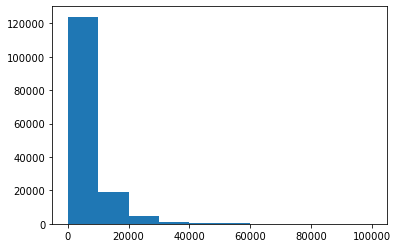

In [22]:
##绘制标签的统计图，查看标签分布
plt.hist(Y_data)
plt.show()
plt.close()

In [23]:
#4.缺失值使用-1填补
X_data = X_data.fillna(-1)
X_test = X_test.fillna(-1)

In [26]:
X_data

,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,v_13,v_14
0,43.357796,3.966344,0.050257,2.159744,1.143786,0.235676,0.101988,0.129549,0.022816,0.097462,-2.881803,2.804097,-2.420821,0.795292,0.914762
1,45.305273,5.236112,0.137925,1.380657,-1.422165,0.264777,0.121004,0.135731,0.026597,0.020582,-4.900482,2.096338,-1.030483,-1.722674,0.245522
2,45.978359,4.823792,1.319524,-0.998467,-0.996911,0.251410,0.114912,0.165147,0.062173,0.027075,-4.846749,1.803559,1.565330,-0.832687,-0.229963
3,45.687478,4.492574,-0.050616,0.883600,-2.228079,0.274293,0.110300,0.121964,0.033395,0.000000,-4.509599,1.285940,-0.501868,-2.438353,-0.478699
4,44.383511,2.031433,0.572169,-1.571239,2.246088,0.228036,0.073205,0.091880,0.078819,0.121534,-1.896240,0.910783,0.931110,2.834518,1.923482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,45.316543,-3.139095,-1.269707,-0.736609,-1.505820,0.280264,0.000310,0.048441,0.071158,0.019174,1.988114,-2.983973,0.589167,-1.304370,-0.302592
149996,45.972058,-3.143764,-0.023523,-2.366699,0.698012,0.253217,0.000777,0.084079,0.099681,0.079371,1.839166,-2.774615,2.553994,0.924196,-0.272160
149997,44.733481,-3.105721,0.595454,-2.279091,1.423661,0.233353,0.000705,0.118872,0.100118,0.097914,2.439812,-1.630677,2.290197,1.891922,0.414931
149998,45.658634,-3.204785,-0.441680,-1.179812,0.620680,0.256369,0.000252,0.081479,0.083558,0.081498,2.075380,-2.633719,1.414937,0.431981,-1.659014


In [27]:
X_data.values

array([[ 4.33577963e+01,  3.96634417e+00,  5.02570942e-02, ...,
        -2.42082079e+00,  7.95291943e-01,  9.14762500e-01],
       [ 4.53052730e+01,  5.23611190e+00,  1.37925324e-01, ...,
        -1.03048284e+00, -1.72267378e+00,  2.45522411e-01],
       [ 4.59783591e+01,  4.82379222e+00,  1.31952415e+00, ...,
         1.56532963e+00, -8.32687327e-01, -2.29962856e-01],
       ...,
       [ 4.47334810e+01, -3.10572092e+00,  5.95453745e-01, ...,
         2.29019700e+00,  1.89192231e+00,  4.14930815e-01],
       [ 4.56586340e+01, -3.20478484e+00, -4.41679891e-01, ...,
         1.41493742e+00,  4.31980594e-01, -1.65901428e+00],
       [ 4.55363833e+01, -3.20032635e+00, -1.61289304e+00, ...,
         3.17235052e-02, -1.48334970e+00, -3.42674348e-01]])

In [29]:
from sklearn.utils.multiclass import type_of_target

In [30]:
type_of_target(Y_data)

'continuous'

In [32]:
from sklearn.preprocessing import LabelEncoder

In [36]:
label_encoder = LabelEncoder()
Y_data = label_encoder.fit_transform(Y_data)

### 模型训练与预测

In [37]:
#model
from sklearn import linear_model
from sklearn import preprocessing
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

#降维
from sklearn.decomposition import PCA,FastICA,FactorAnalysis,SparsePCA
import lightgbm as lgb
import xgboost as xgb

#参数搜索和评价
from sklearn.model_selection import GridSearchCV,cross_val_score,StratifiedKFold,train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [41]:
## xgb-Model
xgr = xgb.XGBRegressor(n_estimators=120, learning_rate=0.1, gamma=0, subsample=0.8,\
        colsample_bytree=0.9, max_depth=7) #,objective ='reg:squarederror'

scores_train = []
scores = []

## 5折交叉验证方式
sk=StratifiedKFold(n_splits=5,shuffle=True,random_state=0)
for train_ind,val_ind in sk.split(X_data,Y_data):
    #train_index ,val_index
    train_x=X_data.iloc[train_ind].values
    train_y=Y_data[train_ind]
    val_x=X_data.iloc[val_ind].values
    val_y=Y_data[val_ind]
    
    xgr.fit(train_x,train_y)
    pred_train_xgb=xgr.predict(train_x)
    pred_xgb=xgr.predict(val_x)
    
    score_train = mean_absolute_error(train_y,pred_train_xgb)
    scores_train.append(score_train)
    score = mean_absolute_error(val_y,pred_xgb)
    scores.append(score)

print('Train mae:',np.mean(score_train))
print('Val mae',np.mean(scores))

D:\Anaconda\lib\site-packages\sklearn\model_selection\_split.py:666: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(("The least populated class in y has only %d"


Train mae: 96.3022596620798
Val mae 104.60210174460731


In [42]:
#define model
def build_model_xgb(x_train,y_train):
    model = xgb.XGBRegressor(n_estimators=150,learning_rate=0.1,gamma=0,subsample=0.8,
                             colsample_bytree=0.9,max_depth=7)
    model.fit(x_train,y_train)
    return model

def build_model_lgb(x_train,y_train):
    estimator = lgb.LGBMRegressor(num_leaves=127,n_estimators=150)
    param_grid = {
        'learning_rate':[0.01,0.05,0.1,0.2]
    }
    gbm = GridSearchCV(estimator,param_grid)
    gbm.fit(x_train,y_train)
    return gbm

In [45]:
#split datasets
x_train,x_val,y_train,y_val = train_test_split(X_data,Y_data,test_size=0.3)

In [49]:
print('Train lgb...')
model_lgb = build_model_lgb(x_train,y_train)
val_lgb = model_lgb.predict(x_val)
MAE_lgb = mean_absolute_error(y_val,val_lgb)
print('MAE of val with lgb:',MAE_lgb)

Train lgb...
MAE of val with lgb: 103.03502849057789


In [50]:
print('Predict lgb...')
model_lgb_pre = build_model_lgb(X_data,Y_data)
subA_lgb = model_lgb.predict(X_test)
print('Sta of Predict lgb:')
Sta_inf(subA_lgb)

Predict lgb...
Sta of Predict lgb:
_min -104.43964398145316
_max: 17480.609516025066
_mean 14118.920610791223
_ptp 17585.049160006518
_std 2730.6191917692013
_var 7456281.170458285


In [51]:
print('Train xgb...')
model_xgb = build_model_xgb(x_train,y_train)
val_xgb = model_xgb.predict(x_val)
MAE_xgb = mean_absolute_error(y_val,val_xgb)
print('MAE of val with xgb:',MAE_xgb)

print('Predict xgb...')
model_xgb_pre = build_model_xgb(X_data,Y_data)
subA_xgb = model_xgb_pre.predict(X_test)
print('Sta of Predict xgb:')
Sta_inf(subA_xgb)

Train xgb...
MAE of val with xgb: 102.49892766659525
Predict xgb...
Sta of Predict xgb:
_min -22.303112
_max: 17544.875
_mean 14118.8955
_ptp 17567.178
_std 2730.4602
_var 7455413.5


In [52]:
#Ensemble model
val_Weighted = (1-MAE_lgb/(MAE_xgb+MAE_lgb))*val_lgb+(1-MAE_xgb/(MAE_xgb+MAE_lgb))*val_xgb
val_Weighted[val_Weighted<0] = 10 #预测值有负数，而负数不存在
print('MAE of val with Weighted ensemble:',mean_absolute_error(y_val,val_Weighted))

MAE of val with Weighted ensemble: 99.76875341883664


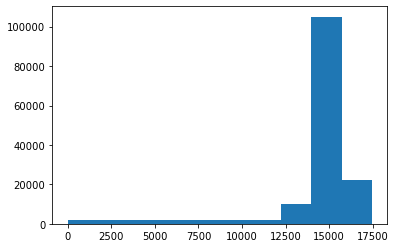

<function matplotlib.pyplot.close(fig=None)>

In [53]:
sub_Weighted = (1-MAE_lgb/(MAE_xgb+MAE_lgb))*subA_lgb+(1-MAE_xgb/(MAE_xgb+MAE_lgb))*subA_xgb

##查看预测值的统计分布
plt.hist(Y_data)
plt.show()
plt.close

In [55]:
sub = pd.DataFrame()
sub['SaleID'] = df_test.SaleID
sub['price'] = sub_Weighted
sub.to_csv('./sub_Weighted.csv',index=False)

In [56]:
sub.head()

,SaleID,price
0,200000,14157.156205
1,200001,14300.814248
2,200002,15342.399323
3,200003,14219.884048
4,200004,9415.313314
